In [1]:
!pip install sentence-transformers torch

In [2]:
from sentence_transformers import SentenceTransformer

In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
text = "Embedding fine-tuning improves retrieval quality in RAG systems."

In [5]:
embedding = model.encode(text)

In [6]:
embedding

array([-4.31954525e-02, -6.37483737e-03,  9.89384800e-02, -5.49361482e-02,
       -1.11686103e-01,  7.33399158e-03,  1.22230127e-02, -3.27670656e-04,
       -1.20244212e-02, -5.08929417e-02, -2.30039805e-02,  6.07165918e-02,
        6.57067895e-02,  1.35162100e-02, -7.56543726e-02,  3.56635377e-02,
        9.49646235e-02,  1.69990420e-01, -8.21337476e-02, -5.11804968e-02,
       -6.61959425e-02,  3.54444534e-02,  6.89547658e-02, -5.40292673e-02,
       -3.87974232e-02, -7.20138615e-03, -8.89522955e-02, -2.07440481e-02,
        1.00668877e-01, -7.00350627e-02, -3.93861569e-02,  5.27502261e-02,
       -2.10089535e-02, -9.75631736e-03, -7.13353306e-02,  2.94415001e-02,
       -7.28627294e-02,  2.83689834e-02, -3.83581296e-02,  2.69834269e-02,
        6.83708000e-04,  8.22034031e-02, -1.09918257e-02,  1.40311336e-02,
        9.09943692e-03,  1.42066488e-02, -2.72481311e-02, -1.92143973e-02,
        1.83158815e-02, -1.99292041e-02, -4.79140691e-02, -6.14971481e-03,
        4.47928011e-02,  

In [9]:
import numpy as np
print("Embedding Shape:", embedding.shape)
print("First 10 Values:", np.round(embedding[:10], 6))

Embedding Shape: (384,)
First 10 Values: [-0.043195 -0.006375  0.098938 -0.054936 -0.111686  0.007334  0.012223
 -0.000328 -0.012024 -0.050893]


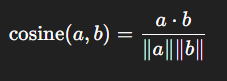

In [11]:
import numpy as np

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

In [12]:
documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

query = "How to improve retrieval in RAG?"

In [13]:
doc_embs = model.encode(documents, convert_to_numpy=True)

In [14]:
q_emb = model.encode(query, convert_to_numpy=True)

In [15]:
scores = [cosine_sim(q_emb, d_emb) for d_emb in doc_embs]

In [17]:
query

'How to improve retrieval in RAG?'

In [16]:
# Print all scores
for doc, score in zip(documents, scores):
    print(f"Score: {score:.4f}  |  {doc}")

Score: 0.7759  |  Embedding fine-tuning improves retrieval in RAG.
Score: 0.0830  |  LoRA reduces GPU memory usage.
Score: 0.0618  |  My car needs fuel.
Score: 0.0565  |  Vector databases store embeddings.


In [18]:
pairs = [
    ("Embedding improves semantic search",
     "Fine-tuned embeddings enhance retrieval"),

    ("Embedding improves semantic search",
     "I bought a new car yesterday"),
]

In [19]:
for s1, s2 in pairs:
    emb1, emb2 = model.encode([s1, s2], normalize_embeddings=True)
    score = cosine_sim(emb1, emb2)
    print(f"\nSentence 1: {s1}")
    print(f"Sentence 2: {s2}")
    print("Cosine Similarity:", round(score, 4))


Sentence 1: Embedding improves semantic search
Sentence 2: Fine-tuned embeddings enhance retrieval
Cosine Similarity: 0.754

Sentence 1: Embedding improves semantic search
Sentence 2: I bought a new car yesterday
Cosine Similarity: 0.0597


## Keyword Search vs Vector Search

In [20]:
import re

documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

In [21]:
query = "How to improve retrieval in RAG?"

In [22]:
# Tokenize function
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

In [23]:
query_tokens = tokenize(query)

In [24]:
query_tokens

['how', 'to', 'improve', 'retrieval', 'in', 'rag']

In [25]:

print("Query tokens:", query_tokens)


Query tokens: ['how', 'to', 'improve', 'retrieval', 'in', 'rag']

=== Keyword Search Scores ===


In [26]:
print("\n=== Keyword Search Scores ===")

for doc in documents:
    doc_tokens = tokenize(doc)

    # Count matching words
    matches = set(query_tokens) & set(doc_tokens)
    score = len(matches)

    print(f"Score: {score} | Matched: {matches} | {doc}")


=== Keyword Search Scores ===
Score: 3 | Matched: {'retrieval', 'in', 'rag'} | Embedding fine-tuning improves retrieval in RAG.
Score: 0 | Matched: set() | LoRA reduces GPU memory usage.
Score: 0 | Matched: set() | My car needs fuel.
Score: 0 | Matched: set() | Vector databases store embeddings.


In [27]:
query

'How to improve retrieval in RAG?'

In [28]:
!pip install rank_bm25

In [29]:
import re
from rank_bm25 import BM25Okapi

In [30]:
documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

In [31]:

query = "How to improve retrieval in RAG?"

In [32]:
def tokenize(text: str):
    return re.findall(r"[a-z0-9]+", text.lower())

In [33]:
tokenized_corpus = [tokenize(d) for d in documents]
tokenized_query  = tokenize(query)

In [34]:
tokenized_corpus

[['embedding', 'fine', 'tuning', 'improves', 'retrieval', 'in', 'rag'],
 ['lora', 'reduces', 'gpu', 'memory', 'usage'],
 ['my', 'car', 'needs', 'fuel'],
 ['vector', 'databases', 'store', 'embeddings']]

In [35]:
tokenized_query

['how', 'to', 'improve', 'retrieval', 'in', 'rag']

In [36]:
bm25 = BM25Okapi(tokenized_corpus)

In [37]:
scores = bm25.get_scores(tokenized_query)

In [38]:
print("=== BM25 Scores (all docs) ===")
for doc, score in zip(documents, scores):
    print(f"{score:.4f} | {doc}")

=== BM25 Scores (all docs) ===
2.1541 | Embedding fine-tuning improves retrieval in RAG.
0.0000 | LoRA reduces GPU memory usage.
0.0000 | My car needs fuel.
0.0000 | Vector databases store embeddings.


## Evaluation of embedding mode

MTEB (Massive Text Embedding Benchmark)

STSBenchmark = Semantic Textual Similarity Benchmark

| Metric                    | Tumhara Score | Typical Range | Quality Level    | Iska Meaning                                      | Practical Impact                                   |
| ------------------------- | ------------- | ------------- | ---------------- | ------------------------------------------------- | -------------------------------------------------- |
| **Spearman (Main Score)** | **0.8203**    | 0.75 – 0.90   | 🟢 Good Baseline | Model ranking human similarity ke kaafi close hai | Semantic search me mostly relevant results milenge |
| Pearson                   | 0.8274        | 0.75 – 0.90   | 🟢 Good          | Linear similarity correlation strong hai          | Cosine similarity reliable hai                     |
| Cosine Spearman           | 0.8203        | 0.75 – 0.90   | 🟢 Good          | Cosine similarity best performing metric hai      | Retrieval me cosine use karo (recommended)         |
| Manhattan Spearman        | 0.8194        | 0.70 – 0.85   | 🟢 Good          | Slightly lower but comparable                     | Rarely used in RAG                                 |
| Euclidean Spearman        | 0.8203        | 0.75 – 0.88   | 🟢 Good          | Cosine ke almost equal                            | Acceptable alternative distance metric             |


| Score Range | Interpretation          | Typical Model Type          |
| ----------- | ----------------------- | --------------------------- |
| < 0.70      | Weak semantic alignment | Poor / old embeddings       |
| 0.70 – 0.78 | Moderate                | Small generic models        |
| 0.78 – 0.83 | **Good Baseline**       | Lightweight models (MiniLM) |
| 0.83 – 0.88 | Strong                  | Fine-tuned mid-size models  |
| 0.88+       | Very Strong / Near SOTA | Large embedding models      |


In [39]:
!pip install mteb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 34.3 MB/s eta 0:00:00


In [40]:
import mteb
from typing import Dict, Any, Optional

def eval_stsbenchmark(
    model_name: str,
    batch_size: int = 32,
    normalize_embeddings: bool = True,
    languages: Optional[list[str]] = None,
) -> Dict[str, Any]:
    """
    Evaluate any embedding model on MTEB STSBenchmark and return key metrics.
    Works with model names supported by mteb.get_model().

    Returns a dict with main metrics + raw result object.
    """
    if languages is None:
        languages = ["eng"]

    # 1) Load model via MTEB
    model = mteb.get_model(model_name)

    # 2) Get task objects
    tasks = mteb.get_tasks(tasks=["STSBenchmark"], languages=languages)

    # 3) Run evaluation
    res = mteb.evaluate(
        model,
        tasks=tasks,
        encode_kwargs={
            "batch_size": batch_size,
            "normalize_embeddings": normalize_embeddings,
        },
    )

    # 4) Extract metrics cleanly
    # res.task_results -> list[TaskResult]
    tr = next((t for t in res.task_results if t.task_name == "STSBenchmark"), None)
    if tr is None:
        raise RuntimeError("STSBenchmark TaskResult not found in results.")

    # scores structure: {'test': [ { ...metrics... } ]}
    test_entry = tr.scores["test"][0]
    out = {
        "model_name": res.model_name,
        "model_revision": res.model_revision,
        "main_score": float(test_entry["main_score"]),
        "spearman": float(test_entry["spearman"]),
        "pearson": float(test_entry["pearson"]),
        "cosine_spearman": float(test_entry["cosine_spearman"]),
        "cosine_pearson": float(test_entry["cosine_pearson"]),
        "euclidean_spearman": float(test_entry["euclidean_spearman"]),
        "manhattan_spearman": float(test_entry["manhattan_spearman"]),
        "languages": test_entry.get("languages"),
        "hf_subset": test_entry.get("hf_subset"),
        "raw": res,  # full ModelResult (in case you need it)
    }

    # Pretty print (optional)
    print("\n=== STSBenchmark (MTEB) ===")
    print(f"Model: {out['model_name']}")
    print(f"Revision: {out['model_revision']}")
    print(f"Main (Spearman): {out['main_score']:.4f}")
    print(f"Spearman: {out['spearman']:.4f} | Pearson: {out['pearson']:.4f}")
    print(
        "Cosine Spearman: {cs:.4f} | Euclidean Spearman: {es:.4f} | Manhattan Spearman: {ms:.4f}".format(
            cs=out["cosine_spearman"],
            es=out["euclidean_spearman"],
            ms=out["manhattan_spearman"],
        )
    )

    return out

E5 = Embedding from E(verything) to E(verything)

Developed by:

Microsoft Research

Popular model name:

intfloat/e5-base-v2

BGE = BAAI General Embedding

Developed by:

Beijing Academy of Artificial Intelligence

Popular models:

BAAI/bge-base-en-v1.5

In [41]:
r1 = eval_stsbenchmark("sentence-transformers/all-MiniLM-L6-v2")
r2 = eval_stsbenchmark("BAAI/bge-base-en-v1.5")
r3 = eval_stsbenchmark("intfloat/e5-base-v2")

README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

 {'query': 'query: ', 'document': 'passage: '}
/usr/local/lib/python3.12/dist-packages/mteb/models/sentence_transformer_wrapper.py:88: UserWarning: Model prompts specified, these will overwrite the default model prompts. Current prompts will be:
 {'query': 'query: ', 'document': 'passage: '}
  warnings.warn(msg)


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]


=== STSBenchmark (MTEB) ===
Model: intfloat/e5-base-v2
Revision: 1c644c92ad3ba1efdad3f1451a637716616a20e8
Main (Spearman): 0.8548
Spearman: 0.8548 | Pearson: 0.8493
Cosine Spearman: 0.8548 | Euclidean Spearman: 0.8548 | Manhattan Spearman: 0.8549


In [42]:
results = [r1, r2, r3]
for r in sorted(results, key=lambda x: x["main_score"], reverse=True):
    print(f"{r['model_name']}: {r['main_score']:.4f}")

BAAI/bge-base-en-v1.5: 0.8642
intfloat/e5-base-v2: 0.8548
sentence-transformers/all-MiniLM-L6-v2: 0.8203


## Training Code

In [34]:
from datasets import load_from_disk
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

In [35]:
# Load base model
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# with inbuilt dataset
# 2. Load dataset
# dataset = load_dataset("sentence-transformers/all-nli", "triplet")
# train_dataset = dataset["train"].select(range(100_000))
# eval_dataset = dataset["dev"]

In [36]:
import zipfile
import os

zip_path = "/content/pharma_ft_data_backup.zip"       # zip file ka path
extract_to = "unzipped_data"     # folder jaha extract karna hai

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzip complete")

Unzip complete


In [37]:
# Load YOUR custom dataset
train_dataset = load_from_disk("/content/unzipped_data/pharma_ft_data/train_pairs")

Arrow file = Apache Arrow columnar format

HuggingFace Datasets internally use karta hai:

Fast memory-mapped storage

Efficient column-based access

Faster training

Low RAM usage

Parallel data loading

Isliye:
Dataset ko JSON me store nahi karta
Arrow binary format me store karta hai.

In [38]:
print("Dataset loaded:", train_dataset)
print("Columns:", train_dataset.column_names)

Dataset loaded: Dataset({
    features: ['anchor', 'positive'],
    num_rows: 8
})
Columns: ['anchor', 'positive']


In [39]:
# Define loss (perfect for anchor-positive pairs)
loss = MultipleNegativesRankingLoss(model)

In [40]:
# Training arguments
args = SentenceTransformerTrainingArguments(
    output_dir="models/pharma-embedding-ft",
    num_train_epochs=3,                  # increase since dataset small
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True,                           # use False if CPU
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    logging_steps=10,
    save_strategy="epoch",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [41]:
# Trainer (NO evaluator needed for pair dataset)
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
)


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [42]:
# Train
trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3, training_loss=0.15489300092061362, metrics={'train_runtime': 37.4165, 'train_samples_per_second': 0.641, 'train_steps_per_second': 0.08, 'total_flos': 0.0, 'train_loss': 0.15489300092061362, 'epoch': 3.0})

In [43]:
# Save model
model.save_pretrained("models/pharma-embedding-ft")

print("Fine-tuned model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved successfully.


In [44]:
import os
import zipfile

def zip_folder_manual(folder_path: str, output_zip_path: str):
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname)

    print(f"[OK] Folder zipped at: {output_zip_path}")


# Example
zip_folder_manual("/content/models", "model_backup.zip")

[OK] Folder zipped at: model_backup.zip


## Inference code

In [45]:
from sentence_transformers import SentenceTransformer

embeddings_model = SentenceTransformer("/content/models/pharma-embedding-ft")

sentences = [
    "How to improve RAG retrieval?",
    "LoRA reduces GPU memory."
]

embeddings = embeddings_model.encode(sentences, normalize_embeddings=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:


# Build FAISS from your Document list
vectorstore = FAISS.from_documents(documents, embeddings)

# Test search
query = "What are the contraindications?"
results = vectorstore.similarity_search(query, k=3)

for i, r in enumerate(results, 1):
    print(f"\n--- Result {i} ---")
    print(r.page_content[:500])

## now lets create a RAG and use the custom finetuned model

In [3]:
!pip install -U langchain
!pip install -U langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.5 MB/s eta 0:00:00


In [6]:
%pip install -qU langchain-community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.3/331.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [8]:
from langchain_community.document_loaders import PyPDFLoader

In [9]:
# Load document using PyPDFLoader document loader
loader = PyPDFLoader("/content/pharma_demo.pdf")
documents = loader.load()

In [10]:
documents

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': 'anonymous', 'creationdate': '2026-02-22T09:30:19+00:00', 'author': 'anonymous', 'keywords': '', 'moddate': '2026-02-22T09:30:19+00:00', 'subject': 'unspecified', 'title': 'untitled', 'trapped': '/False', 'source': '/content/pharma_demo.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='PHARMA PRODUCT DOSSIER (SYNTHETIC)\nProduct: Amoxycillin Capsules 500 mg\nIndication: Treatment of bacterial infections (upper respiratory tract, urinary tract).\nMechanism of Action: Beta-lactam antibiotic; inhibits bacterial cell wall synthesis.\nContraindications: Hypersensitivity to penicillins; history of severe allergy.\nWarnings: Risk of anaphylaxis; monitor for rash; adjust dose in renal impairment.\nDosage & Administration:\n- Adults: 500 mg every 8 hours.\n- Renal impairment: dose adjustment required based on creatinine clearance.\nAdverse Reactions:\n- Common: nausea, diarrhea, rash.\n- Seriou

In [11]:
len(documents)

3

In [13]:
# !pip install langchain-text-splitters

In [23]:
# from langchain_text_splitters import CharacterTextSplitter
# splitter = CharacterTextSplitter(
#     separator="\n\n",
#     chunk_size=20,
#     chunk_overlap=15
# )

In [25]:
# chunks = splitter.split_documents(documents)

In [30]:
# chunks

In [31]:
# print(len(chunks))

In [49]:
from langchain_community.vectorstores.faiss import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [50]:
# your fine-tuned SentenceTransformer model path
MODEL_PATH = "/content/models/pharma-embedding-ft"

# Embedding object (has embed_documents + embed_query)
embeddings = HuggingFaceEmbeddings(
    model_name=MODEL_PATH,
    model_kwargs={"device": "cuda"},          # change to "cpu" if needed
    encode_kwargs={"normalize_embeddings": True}
)

/tmp/ipython-input-2375693854.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [53]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 38.0 MB/s eta 0:00:00


In [54]:
#loading the data and correspond embedding into the FAISS
vectorstore = FAISS.from_documents(documents, embeddings)

In [57]:
vectorstore.save_local("faiss_index_")

In [55]:
results = vectorstore.similarity_search("What are the warnings and precautions?", k=1)

In [56]:
for r in results:
    print("----")
    print(r.page_content)

----
PHARMA PRODUCT DOSSIER (SYNTHETIC)
Product: Amoxycillin Capsules 500 mg
Indication: Treatment of bacterial infections (upper respiratory tract, urinary tract).
Mechanism of Action: Beta-lactam antibiotic; inhibits bacterial cell wall synthesis.
Contraindications: Hypersensitivity to penicillins; history of severe allergy.
Warnings: Risk of anaphylaxis; monitor for rash; adjust dose in renal impairment.
Dosage & Administration:
- Adults: 500 mg every 8 hours.
- Renal impairment: dose adjustment required based on creatinine clearance.
Adverse Reactions:
- Common: nausea, diarrhea, rash.
- Serious: anaphylaxis, C. difficile-associated diarrhea (rare).


In [58]:
retriever = vectorstore.as_retriever()

In [72]:
import os
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [73]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

In [75]:
llm.invoke("hi")

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************kLYA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [59]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [66]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [67]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    """You are a helpful assistant.
Use the following context to answer the question. If you don't know, say you don't know.

Context:
{context}

Question:
{question}

Answer:"""
)

In [68]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [69]:
# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

NameError: name 'llm' is not defined

In [ ]:
rag_chain.invoke("What are the contraindications for Amoxycillin 500 mg?")

In [ ]:
# What are the contraindications for Amoxycillin 500 mg?
# How does Amoxycillin work and how is it eliminated from the body?